In [1]:
# ============================================================
# FIG. 4 REPRODUCTION
# Adiabatic preparation of normal phase states
#
# Reproduces:
#   Fig. 4(a,b): minimum adiabatic time for F >= 0.97
#   Fig. 4(c,d): local fidelity Floc
#
# Based on:
#   Li et al. arXiv:2210.07985
# ============================================================


In [2]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from functools import reduce

# ============================================================
# Basic single-site operators
# ============================================================

def field_operators(nq, mu=1.0):

    Nphi = 2**nq

    alpha = np.arange(Nphi)

    # Eq. (12)
    dphi = np.sqrt(2*np.pi/(Nphi * mu))

    # Eq. (11)
    phi_vals = dphi * (alpha - (Nphi - 1)/2)

    Phi = np.diag(phi_vals)

    # -------------------------------------------------
    # Centered Fourier transform: Eq. (13)
    # -------------------------------------------------

    a = alpha - (Nphi - 1)/2

    F = np.exp(
        1j * 2*np.pi/Nphi * np.outer(a, a)
    ) / np.sqrt(Nphi)

    # Eq. (10)
    Pi = mu * (F @ Phi @ F.conj().T)

    # enforce Hermiticity numerically
    Pi = 0.5 * (Pi + Pi.conj().T)

    return Phi, Pi

In [3]:
# ============================================================
# Embedding utility
# ============================================================

def embed(op, site, nsites, dim):
    """
    Embed single-site operator into full Hilbert space.
    """
    ops = []

    for i in range(nsites):
        if i == site:
            ops.append(op)
        else:
            ops.append(np.eye(dim))

    return reduce(np.kron, ops)


In [4]:
# ============================================================
# Build local Hamiltonian
# ============================================================

def build_Hloc(nsites, nq, mI2, lamI, mu=1.0):

    Phi, Pi = field_operators(nq, mu)
    dim = 2**nq

    Hloc = np.zeros((dim**nsites, dim**nsites), dtype=complex)

    for j in range(nsites):

        Phi_j = embed(Phi, j, nsites, dim)
        Pi_j  = embed(Pi,  j, nsites, dim)

        Hloc += (
            0.5 * Pi_j @ Pi_j
            + 0.5 * mI2 * Phi_j @ Phi_j
            + lamI/24 * Phi_j @ Phi_j @ Phi_j @ Phi_j
        )

    return Hloc

In [5]:
# ============================================================
# Build coupling Hamiltonian
# ============================================================

def build_Hc(nsites, nq, m02, lam0, mI2, lamI, mu=1.0):

    Phi, Pi = field_operators(nq, mu)
    dim = 2**nq

    Hc = np.zeros((dim**nsites, dim**nsites), dtype=complex)

    for j in range(nsites):
        if nsites == 2:
            bond_factor = 0.25
        else:
            bond_factor = 0.5
        jp = (j + 1) % nsites

        Phi_j  = embed(Phi, j,  nsites, dim)
        Phi_jp = embed(Phi, jp, nsites, dim)

        # nearest-neighbor coupling
        Hc += bond_factor * (Phi_jp - Phi_j) @ (Phi_jp - Phi_j)

        # delta mass
        Hc += bond_factor * (m02 - mI2) * (Phi_j @ Phi_j)

        # delta lambda
        dlam = lam0 - lamI

        Hc += dlam/24 * (
            Phi_j @ Phi_j @ Phi_j @ Phi_j
        )

    return Hc



In [6]:
# ============================================================
# Full Hamiltonian
# ============================================================

def build_full_H(nsites, nq, m02, lam0, mu=1.0):

    Phi, Pi = field_operators(nq, mu)
    dim = 2**nq

    H = np.zeros((dim**nsites, dim**nsites), dtype=complex)
    if nsites == 2:
        bond_factor = 0.25
    else:
        bond_factor = 0.5
    for j in range(nsites):

        jp = (j + 1) % nsites

        Phi_j  = embed(Phi, j,  nsites, dim)
        Phi_jp = embed(Phi, jp, nsites, dim)
        Pi_j   = embed(Pi,  j,  nsites, dim)

        H += (
            0.5 * Pi_j @ Pi_j
            + 0.5 * m02 * Phi_j @ Phi_j
            + bond_factor * (Phi_jp - Phi_j) @ (Phi_jp - Phi_j)
            + lam0/24 * Phi_j @ Phi_j @ Phi_j @ Phi_j
        )

    return H


In [7]:
# ============================================================
# Ground state
# ============================================================

def ground_state(H):

    vals, vecs = la.eigh(H)

    idx = np.argmin(vals)

    return vals[idx], vecs[:, idx]



In [8]:
# ============================================================
# Build product local ground state
# ============================================================

def local_product_state(nsites, nq, mI2, lamI):

    Phi, Pi = field_operators(nq)

    H1 = (
        0.5 * Pi @ Pi
        + 0.5 * mI2 * Phi @ Phi
        + lamI/24 * Phi @ Phi @ Phi @ Phi
    )

    _, psi1 = ground_state(H1)

    psi = psi1

    for _ in range(nsites - 1):
        psi = np.kron(psi, psi1)

    return psi


In [9]:
# ============================================================
# Adiabatic evolution
# ============================================================

def adiabatic_evolution(psi0,Hloc,Hc,T,steps=100):
    dt = 0.01
    steps = int(T/dt)
    

    psi = psi0.copy()

    for n in range(steps):

        s = n / steps

        Hs = Hloc + s * Hc

        U = la.expm(-1j * Hs * dt)

        psi = U @ psi

    psi /= np.linalg.norm(psi)

    return psi


In [10]:
# ============================================================
# Fidelity
# ============================================================

def fidelity(psi, target):

    return np.abs(np.vdot(target, psi))**2


# ============================================================
# Local fidelity Eq. (52)
# ============================================================

def local_fidelity(target_state, local_state, nsites, nq):

    dim = 2**nq

    psi = target_state.reshape([dim]*nsites)

    # trace out all except site 0
    rho = np.tensordot(
        psi.conj(),
        psi,
        axes=([i for i in range(1, nsites)],
              [i for i in range(1, nsites)])
    )

    return np.real(
        local_state.conj().T @ rho @ local_state
    )



In [11]:
# ============================================================
# Find minimum T for fidelity >= threshold
# ============================================================

def find_min_T(
    nsites,
    nq,
    m02,
    lam0,
    mI2,
    fidelity_target=0.97
):

    # ----- target state -----
    Hfull = build_full_H(nsites, nq, m02, lam0)

    _, psi_target = ground_state(Hfull)

    # ----- local state -----
    psi_local = local_product_state(
        nsites,
        nq,
        mI2,
        lam0
    )

    # ----- adiabatic pieces -----
    Hloc = build_Hloc(nsites, nq, mI2, lam0)

    Hc = build_Hc(
        nsites,
        nq,
        m02,
        lam0,
        mI2,
        lam0
    )

    # ----- scan T -----
    Ts = np.arange(1, 120, 0.25)

    for T in Ts:

        psi_final = adiabatic_evolution(psi_local,Hloc,Hc,T)

        F = fidelity(psi_final, psi_target)

        if F >= fidelity_target:

            # local fidelity
            Phi, Pi = field_operators(nq)

            H1 = (
                0.5 * Pi @ Pi
                + 0.5 * mI2 * Phi @ Phi
                + lam0/24 * Phi @ Phi @ Phi @ Phi
            )

            _, psi1 = ground_state(H1)

            Floc = local_fidelity(
                psi_target,
                psi1,
                nsites,
                nq
            )

            return T, Floc

    return np.nan, np.nan

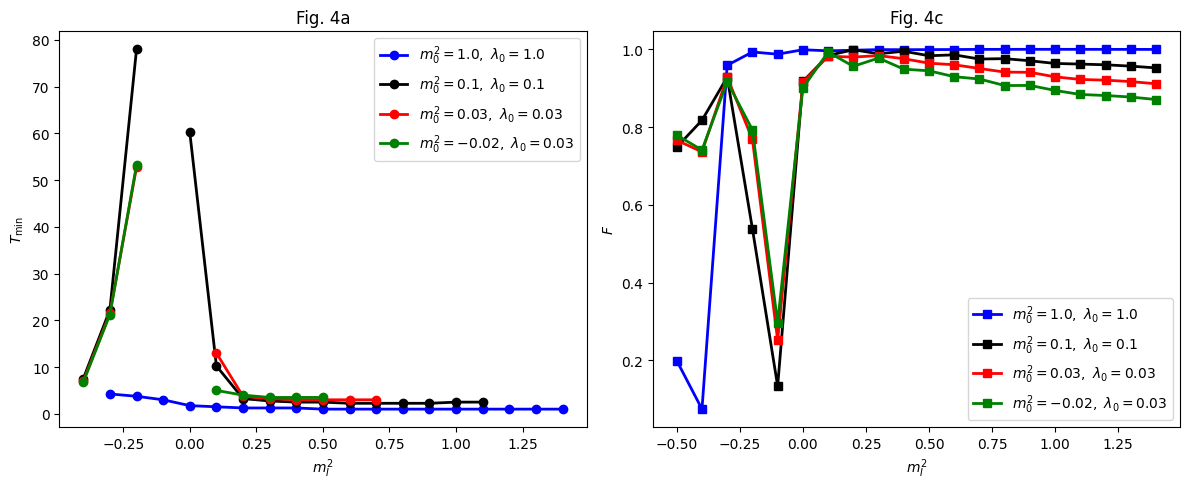

In [12]:
# ============================================================
# Reproduce Fig. 4a and Fig. 4c
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Common settings
# ------------------------------------------------------------
# colours for the four curves
colors = ['blue', 'black', 'red', 'green']
nq = 2
nsites = 2

# parameter sets:
# (m0^2, lambda0)

param_sets = [
    (1.0,   1.0),
    (0.1,   0.1),
    (0.03,  0.03),
    (-0.02, 0.03)
]

# scan over mI^2
mI2_vals = np.arange(-0.5, 1.5, 0.1)

# ============================================================
# FIGURE 4a
# Tmin vs mI^2
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12,5))

for i, (m02, lam0) in enumerate(param_sets):

    Tmin_list = []

    for mI2 in mI2_vals:

        T_min, Floc = find_min_T(
            nsites=nsites,
            nq=nq,
            m02=m02,
            lam0=lam0,
            mI2=mI2,
            fidelity_target=0.97
        )

        Tmin_list.append(T_min)

    ax[0].plot(
        mI2_vals,
        Tmin_list,
        'o-',
        lw=2,
        color=colors[i],
        label=rf'$m_0^2={m02},\ \lambda_0={lam0}$'
    )

ax[0].set_xlabel(r'$m_I^2$')
ax[0].set_ylabel(r'$T_{\min}$')

ax[0].set_title(r'Fig. 4a')

ax[0].legend()

# ============================================================
# FIGURE 4c
# Fidelity vs mI^2
# ============================================================

for i, (m02, lam0) in enumerate(param_sets):

    F_list = []

    for mI2 in mI2_vals:

        # ----- target -----
        Hfull = build_full_H(
            nsites,
            nq,
            m02,
            lam0
        )

        _, psi_target = ground_state(Hfull)

        # ----- local state -----
        psi_local = local_product_state(
            nsites,
            nq,
            mI2,
            lam0
        )

        # ----- Hloc and Hc -----
        Hloc = build_Hloc(
            nsites,
            nq,
            mI2,
            lam0
        )

        Hc = build_Hc(
            nsites,
            nq,
            m02,
            lam0,
            mI2,
            lam0
        )

        psi_final = adiabatic_evolution(
            psi_local,
            Hloc,
            Hc,
            T=25
        )

        F = fidelity(
            psi_final,
            psi_target
        )

        F_list.append(F)

    ax[1].plot(
        mI2_vals,
        F_list,
        's-',
        lw=2,
        color=colors[i],
        label=rf'$m_0^2={m02},\ \lambda_0={lam0}$'
    )
ax[1].set_xlabel(r'$m_I^2$')
ax[1].set_ylabel(r'$F$')

ax[1].set_title(r'Fig. 4c')

ax[1].legend()

plt.tight_layout()
plt.show()